# Introducción a PyMC

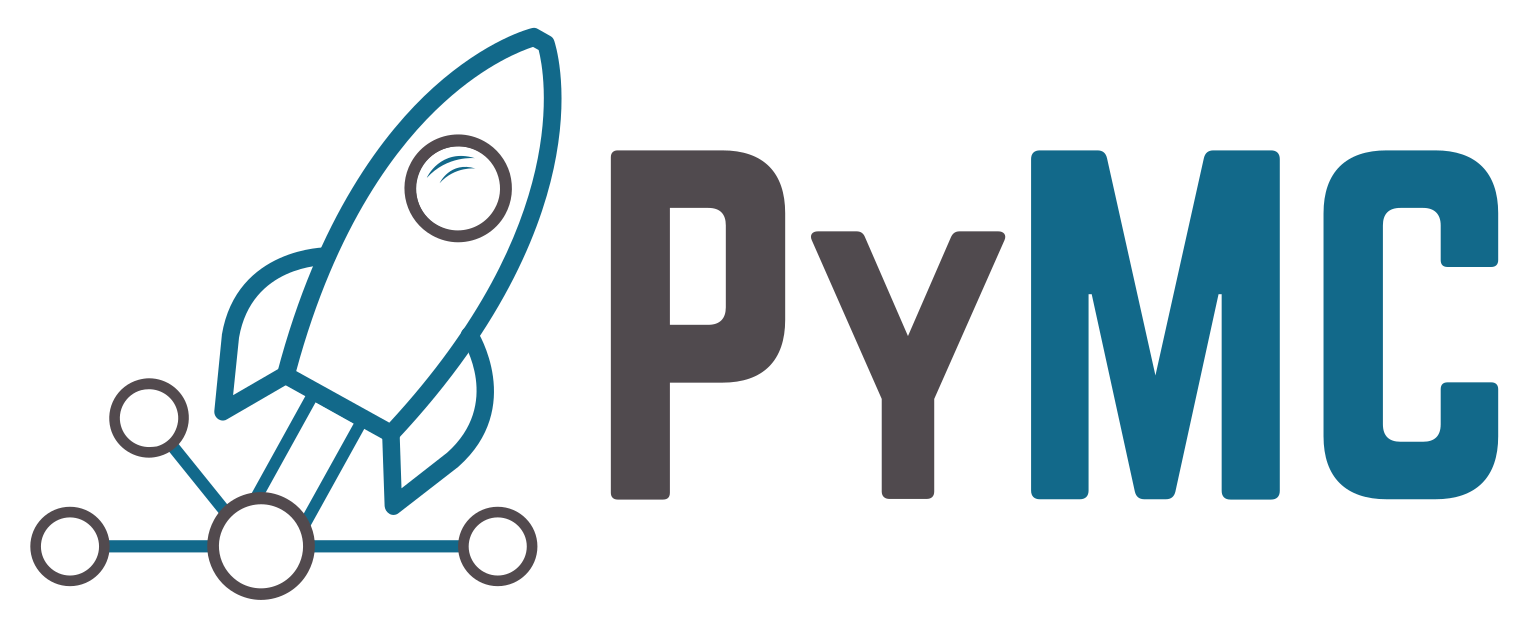

Hasta ahora hemos visto modelos Bayesianos básicos usando un enfoque de inferencia exacta. Vimos las dificultades de este enfoque y que no es aplicable en general, y por eso estudiamos métodos de muestreo que nos permiten hacer inferencia aproximada de la distribución posterior. En este módulo estudiaremos la API de la librería `PyMC`, que nos permite hacer inferencia aproximada sin preocuparnos mucho por los motores de inferencia como tal, y sí en el modelado.

> **Objetivos:**
> - Estudiar la API de `PyMC`, en particular las funciones para crear modelos, definir variables aleatorias previas y verosimilitudes, hacer inferencia y el muestreo de la distribución posterior predictiva.

> **Referencias:**
> - https://www.pymc.io/projects/examples/en/latest/introductory/api_quickstart.html

___

In [1]:
import numpy as np

In [2]:
T = np.array([
    [0.4, 0.5, 0.5],
    [0.3, 0.5, 0.5],
    [0.3, 0.0, 0.0]
])

In [ ]:
p0 = np.array([1, 0, 0])
p1 = T.dot(p0)
p2 = np.linalg.matrix_power(T, 2).dot(p0)  # T.dot(p1)
p3 = np.linalg.matrix_power(T, 3).dot(p0)  # T.dot(p2)
p1, p2, p3

(array([0.4, 0.3, 0.3]),
 array([0.46, 0.42, 0.12]),
 array([0.454, 0.408, 0.138]))

In [6]:
p100 = np.linalg.matrix_power(T, 100).dot(p0)
p1000 = np.linalg.matrix_power(T, 1000).dot(p0)
p100, p1000

(array([0.45454545, 0.40909091, 0.13636364]),
 array([0.45454545, 0.40909091, 0.13636364]))

___

In [7]:
import matplotlib.pyplot as plt
import numpy as np
import arviz as az
import pymc as pm

g++ not available, if using conda: `conda install gxx`


In [8]:
RANDOM_SEED = 8927
rng = np.random.default_rng(RANDOM_SEED)
az.style.use("arviz-darkgrid")

## 1. Creación de modelos

Los modelos en PyMC se crean con la clase `Model`. Dentro de esta clase, se codifican todas las variables aleatorias y sus relaciones, y la clase se encarga de calcular la log probabilidad del modelo y sus gradientes (necesarias para H-MCMC). Normalmente usamos el administrador de contextos para instanciar el modelo:

In [9]:
# Instanciación básica de un modelo
with pm.Model() as model:
    # Definición de las variables aleatorias (modelo)
    pass

Dentro del modelo, definimos las variables aleatorias necesarias:

In [10]:
# Modelo básico: verosimilitud normal con varianza conocida, previa normal
with pm.Model() as model:
    # Previa
    theta = pm.Normal("theta", mu=2, sigma=1)
    # Verosimilitud
    x = pm.Normal("x", mu=theta, sigma=1, observed=[5])

In [11]:
# Inspección de las variables aleatorias básicas
model.basic_RVs

[theta, x]

In [12]:
# Inspección de las variables aleatorias libres
model.free_RVs

[theta]

In [13]:
# Inspección de las variables aleatorias observadas
model.observed_RVs

[x]

In [14]:
# Cálculo de logp
model.compile_logp()({"theta": 0})

array(-16.33787707)

In [15]:
# Cálculo de gradientes de logp
model.compile_dlogp()({"theta": 0})

array([7.])

## 2. Distribuciones de probabilidad

Todo programa probabilístico consiste de variables aleatorias observadas y no observadas. 

- Las variables aleatorias observadas, se definen a través de distribuciones de verosimilitud (recordar verosimilitud = p(datos | parámetros)),
- mientras que las variables aleatorias no observadas se definien a través de distribuciones previas.

Acá [el catálogo de distribuciones de probabilidad de PyMC](https://www.pymc.io/projects/docs/en/stable/api/distributions.html#api-distributions).

### Variables aleatorias no observadas

Las variables aleatorias no observadas tienen como argumentos:

- name: str
- parameter keyword arguments

Por ejemplo, para una distribución normal:

In [16]:
# Variable aleatoria normal x no observada (previa)
with pm.Model():
    x = pm.Normal("x", mu=0, sigma=1)

### Variables aleatorias observadas

Tienen los mismos argumentos que las no observadas, y adicionalmente requieren que pasemos los datos observados:

- observed

In [17]:
# Variable aleatoria normal x observada (verosimilitud)
with pm.Model():
    x = pm.Normal("x", mu=0, sigma=1, observed=rng.normal(0, 1, 100))

### Transformaciones deterministas

PyMC permite hacer cálculos algebraicos con variables aleatorias:

In [18]:
# Variables aleatorias no observadas x, y y transformaciones deterministas
with pm.Model():
    x = pm.Normal("x", mu=0, sigma=1)
    y = pm.Gamma("y", alpha=1, beta=1)
    # x + 2
    plus_2 = x + 2
    # x + y
    sum_x_y = x + y
    # x ** 2
    squared = x ** 2
    # sin(x)
    sin_x = pm.math.sin(x)

Estas transformaciones trabajan correctamente, sin embargo, los resultados de las mismas no se guardan automáticamente. Si queremos que PyMC lleve registro de las variables transformadas, debemos usar `pm.Deterministic`:

In [19]:
# Uso de deterministic
with pm.Model():
    x = pm.Normal("x", mu=0, sigma=1)
    y = pm.Gamma("y", alpha=1, beta=1)
    # x + 2
    plus_2 = pm.Deterministic("plus_2", x + 2)
    # x + y
    sum_x_y = pm.Deterministic("sum_x_y", x + y)
    # x ** 2
    squared = pm.Deterministic("squared", x ** 2)
    # sin(x)
    sin_x = pm.Deterministic("sin_x", pm.math.sin(x))

### Variables aleatorias de alto orden

Ya vimos cómo crear variables aleatorias de una dimension (escalares). En varios contextos querremos crear variables aleatorias de múltiples dimensiones.

La mejor práctica para hacer esto es:

In [20]:
# Coordenadas por ciudad
coords = {"cities": ["Santiago", "Mumbai", "Tokyo"]}
# Modelo de múltiples variables aleatorias relativas a ciudades
with pm.Model(coords=coords) as model:
    # Previa normal por ciudad
    x = pm.Normal("x", mu=0, sigma=1, dims="cities")

In [21]:
# Shape de las variables aleatorias
model.eval_rv_shapes()

{'x': (np.int64(3),)}

## 3. Inferencia

Una vez hemos definido nuestro modelo, debemos aplicar inferencia para aproximar la distribución posterior.

### Muestreo
El punto principal de entrada a los algoritmos de muestreo por MCMC es con la función `pm.sample()`. Por defecto, esta función asigna el muestreador adecuado. La función `pm.sample()` devuelve un objeto `arviz.InferenceData`, los cuales contienen toda la información del muestreo realizado. Adicionalmente, se pueden enriquecer con más datos como las muestras de la **posterior predictiva**, y combinan perfectamente con la librería ArviZ para visualización.

Retomemos el modelo básico: verosimilitud normal con varianza conocida, previa normal

In [22]:
# Modelo básico: verosimilitud normal con varianza conocida, previa normal
with pm.Model() as model:
    # Previa
    theta = pm.Normal("theta", mu=2, sigma=1)
    # Verosimilitud
    x = pm.Normal("x", mu=theta, sigma=1, observed=[5])
    # muestreo
    idata = pm.sample(2000)

NUTS[nutpie]: [theta]


Output()

In [23]:
# Objeto de trazas de muestreo
idata

<xarray.DataTree>
Group: /
├── Group: /posterior
│       Dimensions:  (chain: 4, draw: 2000)
│       Coordinates:
│         * chain    (chain) int64 32B 0 1 2 3
│         * draw     (draw) int64 16kB 0 1 2 3 4 5 6 ... 1994 1995 1996 1997 1998 1999
│       Data variables:
│           theta    (chain, draw) float64 64kB 3.726 3.77 3.77 ... 3.578 3.578 3.578
│       Attributes:
│           created_at:                 2026-09-22T02:07:27.585472+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.2.0
│           creation_library_language:  Python
│           sample_dims:                ['chain', 'draw']
│           inference_library:          nutpie
│           inference_library_version:  0.16.11
│           sampling_time:              0.18277382850646973
│           tuning_steps:               400
├── Group: /sample_stats
│       Dimensions:                   (chain: 4, draw: 2000)
│       Coordinates:
│         * chain                     (chain) int64 32B 0 1 2 3
│         * draw                      (draw) int64 16kB 0 1 2 3 ... 1996 1997 1998 1999
│       Data variables: (12/20)
│           depth                     (chain, draw) uint64 64kB 1 1 1 2 1 ... 1 1 2 1 1
│           maxdepth_reached          (chain, draw) bool 8kB False False ... False False
│           step_size                 (chain, draw) float64 64kB 1.305 1.347 ... 1.218
│           transformation_update_id  (chain, draw) int64 64kB 0 0 0 0 0 0 ... 0 0 0 0 0
│           step_size_bar             (chain, draw) float64 64kB 1.329 1.329 ... 1.259
│           mean_tree_accept          (chain, draw) float64 64kB 0.9799 ... 0.6137
│           ...                        ...
│           fisher_distance           (chain, draw) float64 64kB 3.356e-30 ... 1.56e-30
│           transformation_index      (chain, draw) int64 64kB 337 337 337 ... 337 337
│           diverging                 (chain, draw) bool 8kB False False ... False False
│           divergence_draw           (chain, draw) uint64 64kB 0 0 0 0 0 ... 0 0 0 0 0
│           divergence_message        (chain, draw) object 64kB None None ... None None
│           divergence_energy_error   (chain, draw) float64 64kB nan nan nan ... nan nan
│       Attributes:
│           created_at:                  2026-09-22T02:07:27.571999+00:00
│           creation_library:            ArviZ
│           creation_library_version:    1.2.0
│           creation_library_language:   Python
│           sample_dims:                 ['chain', 'draw']
│           inference_library:           nutpie
│           inference_library_version:   0.16.11
│           inference_library_settings:  {"sampler": "nuts", "adaptation": "diag", "s...
├── Group: /constant_data
│       Attributes:
│           created_at:                 2026-09-22T02:07:27.579510+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.2.0
│           creation_library_language:  Python
│           inference_library:          pymc
│           inference_library_version:  6.2.0
│           sample_dims:                []
└── Group: /observed_data
        Dimensions:  (x_dim_0: 1)
        Coordinates:
          * x_dim_0  (x_dim_0) int64 8B 0
        Data variables:
            x        (x_dim_0) float64 8B 5.0
        Attributes:
            created_at:                 2026-09-22T02:07:27.582777+00:00
            creation_library:           ArviZ
            creation_library_version:   1.2.0
            creation_library_language:  Python
            inference_library:          pymc
            inference_library_version:  6.2.0
            sample_dims:                []

El modelo contiene exclusivamente variables continuas, por lo que PyMC asignó el muestreador NUTS, el cuál es un muestreador basado en HMC con ciertas características adicionales, y es bastante efectivo para incluso modelos complejos.

Si no se especifican el número de `chains` (cadenas de Markov), se determina automáticamente por el número de núcleos CPU disponibles:

In [24]:
# Dims de las posteriores
idata.posterior.dims

Frozen(ChainMap({'chain': 4, 'draw': 2000}, {}))

Entonces, podemos observar que se muestrearon 2000 valores de cada cadena:

In [25]:
# Para mu, shape
idata.posterior["theta"].shape

(4, 2000)

Si queremos observar las muestras de una cadena en específico:

In [26]:
# Para mu, cadena 2, shape
idata.posterior["theta"].sel(chain=2).shape

(2000,)

### Analizamos los resultados

El gráfico más común para analiza rlos resultados es el llamado trace-plot:

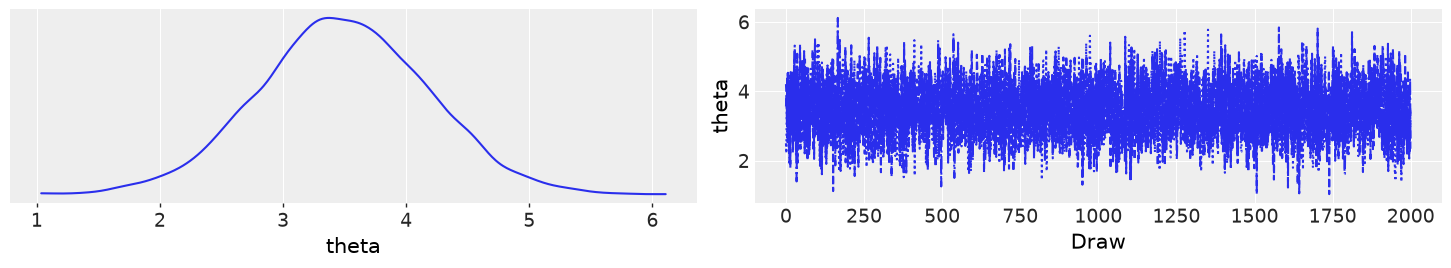

In [27]:
# plot_trace_dist
az.plot_trace_dist(idata, combined=True)

Del lado izquierdo observamos las distribuciones posteriores ajustadas a las muestras (para cada cadena), mientras que del lado derecho observamos las muestras como tal.

También podemos ver algunos estadísticos en una tabla:

In [28]:
# summary
az.summary(idata, kind="stats")

,mean,sd,eti89_lb,eti89_ub
theta,3.5,0.69,2.4,4.6


Y la misma información de forma gráfica:

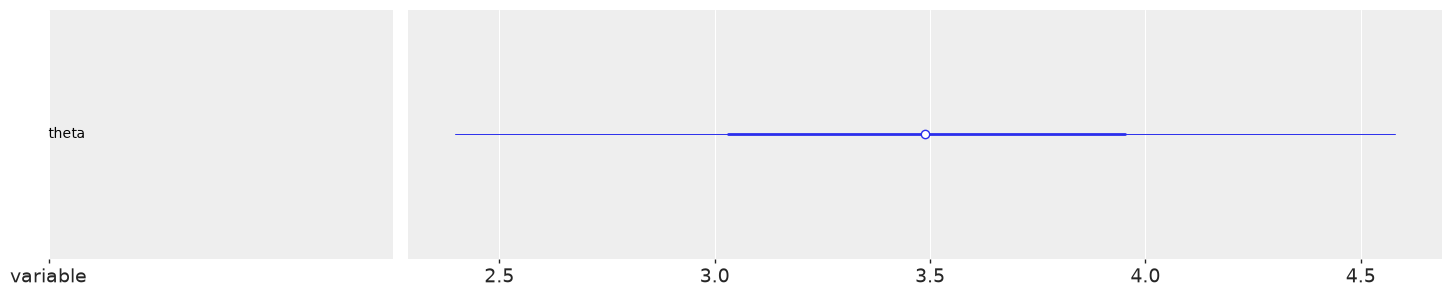

In [29]:
# plot_forest
az.plot_forest(idata, combined=True)

## 4. Muestreo posterior predictivo

En la clase 4, cuando vimos el tema de actualización Beyesiana, comentamos que después de encontrar la distribución posterior, la podíamos usar para hacer predicciones del experimento. En este contexto, estamos generando muestras para aproximar la posterior, y podemos usar dichas muestras como si fueran muestras de la posterior para hacer predicciones:

In [30]:
# Nuevo modelo, incluyendo previa para la desviación estándar
data = rng.standard_normal(100)
with pm.Model() as model:
    # Previas
    mu = pm.Normal("mu", mu=0, sigma=1)
    sd = pm.HalfNormal("sd", sigma=1)
    # Verosimilitud
    obs = pm.Normal("obs", mu=mu, sigma=sd, observed=data)
    # Muestreo de las distribuciones posteriores
    idata = pm.sample()

NUTS[nutpie]: [mu, sd]


Output()

In [31]:
# Incluimos muestras de la posterior predictiva
with model:
    pm.sample_posterior_predictive(idata, extend_inferencedata=True)

Sampling: [obs]


Output()

In [32]:
# Objeto de trazas de muestreo con posterior predictiva
idata

<xarray.DataTree>
Group: /
├── Group: /posterior
│       Dimensions:  (chain: 4, draw: 1000)
│       Coordinates:
│         * chain    (chain) int64 32B 0 1 2 3
│         * draw     (draw) int64 8kB 0 1 2 3 4 5 6 7 ... 993 994 995 996 997 998 999
│       Data variables:
│           mu       (chain, draw) float64 32kB 0.1453 0.05494 0.2022 ... 0.1201 0.2172
│           sd       (chain, draw) float64 32kB 1.038 1.187 1.116 ... 1.038 1.038 1.045
│       Attributes:
│           created_at:                 2026-09-22T02:16:09.014667+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.2.0
│           creation_library_language:  Python
│           sample_dims:                ['chain', 'draw']
│           inference_library:          nutpie
│           inference_library_version:  0.16.11
│           sampling_time:              0.17850375175476074
│           tuning_steps:               400
├── Group: /sample_stats
│       Dimensions:                   (chain: 4, draw: 1000)
│       Coordinates:
│         * chain                     (chain) int64 32B 0 1 2 3
│         * draw                      (draw) int64 8kB 0 1 2 3 4 ... 995 996 997 998 999
│       Data variables: (12/20)
│           depth                     (chain, draw) uint64 32kB 1 2 2 1 2 ... 1 1 2 1 2
│           maxdepth_reached          (chain, draw) bool 4kB False False ... False False
│           step_size                 (chain, draw) float64 32kB 1.024 1.055 ... 1.186
│           transformation_update_id  (chain, draw) int64 32kB 0 0 0 0 0 0 ... 0 0 0 0 0
│           step_size_bar             (chain, draw) float64 32kB 1.125 1.125 ... 1.133
│           mean_tree_accept          (chain, draw) float64 32kB 0.8619 ... 0.7486
│           ...                        ...
│           fisher_distance           (chain, draw) float64 32kB 0.01441 ... 0.007985
│           transformation_index      (chain, draw) int64 32kB 337 337 337 ... 337 337
│           diverging                 (chain, draw) bool 4kB False False ... False False
│           divergence_draw           (chain, draw) uint64 32kB 0 0 0 0 0 ... 0 0 0 0 0
│           divergence_message        (chain, draw) object 32kB None None ... None None
│           divergence_energy_error   (chain, draw) float64 32kB nan nan nan ... nan nan
│       Attributes:
│           created_at:                  2026-09-22T02:16:08.968276+00:00
│           creation_library:            ArviZ
│           creation_library_version:    1.2.0
│           creation_library_language:   Python
│           sample_dims:                 ['chain', 'draw']
│           inference_library:           nutpie
│           inference_library_version:   0.16.11
│           inference_library_settings:  {"sampler": "nuts", "adaptation": "diag", "s...
├── Group: /constant_data
│       Attributes:
│           created_at:                 2026-09-22T02:16:09.006337+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.2.0
│           creation_library_language:  Python
│           inference_library:          pymc
│           inference_library_version:  6.2.0
│           sample_dims:                []
├── Group: /observed_data
│       Dimensions:    (obs_dim_0: 100)
│       Coordinates:
│         * obs_dim_0  (obs_dim_0) int64 800B 0 1 2 3 4 5 6 7 ... 93 94 95 96 97 98 99
│       Data variables:
│           obs        (obs_dim_0) float64 800B -0.5195 -0.08841 ... -1.055 -0.2171
│       Attributes:
│           created_at:                 2026-09-22T02:16:27.946231+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.2.0
│           creation_library_language:  Python
│           inference_library:          pymc
│           inference_library_version:  6.2.0
│           sample_dims:                []
└── Group: /posterior_predictive
        Dimensions:    (chain: 4, draw: 1000, obs_dim_0: 100)
        Coordinates:
          * chain      (chain) int64 32B 0

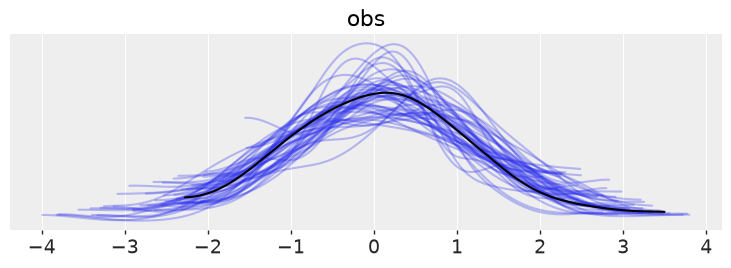

In [33]:
# Gráfica de las muestras de la posterior predictiva vs. los datos observados - plot_ppc_dist
az.plot_ppc_dist(idata)

### Predicciones sobre datos no vistos

En muchas ocasiones queremos predecir datos no vistos por el modelo. Esto es especialmente relevante en "Probabilistic Machine Learning" y "Bayesian Deep Learning". 

`PyMC` incluye una variable tipo `MutableData` que es apropiada para estos usos. Este tipo de variable permite que los valores de los datos puedan ser cambiados posteriormente.

Esta distinción es muy importante, dado que internamente los modelos en `PyMC` son expresiones simbólicas gigantes, por lo que cuando pasamos datos observados, `PyMC` hace optimizaciones tratando estos datos como constantes y no como variables. Por tanto, si se necesita cambiar estos datos después, no sería posible si no usamos variables tipo `MutableData`.

El ejemplo a continuación es de una regresión logística:

In [34]:
x = rng.standard_normal(100)
y = x > 0

with pm.Model() as model:
    # Variables mutables que pueden ser cambiadas después de la creación del modelo
    x_obs = pm.Data("x_obs", x, dims="idx")
    y_obs = pm.Data("y_obs", y, dims="idx")

    coeff = pm.Normal("x", mu=0, sigma=1)
    logistic = pm.math.sigmoid(coeff * x_obs)
    pm.Bernoulli("obs", p=logistic, observed=y_obs, dims="idx")
    idata = pm.sample()

NUTS[nutpie]: [x]


Output()

In [35]:
with model:
    # Cambiamos los datos observados
    pm.set_data(
        {
            "x_obs": [-1, 0, 1.0],
            "y_obs": [False, False, False],
        },
        coords={"idx": [1001, 1002, 1003]},
    )

    pm.sample_posterior_predictive(idata, extend_inferencedata=True)

Sampling: [obs]


Output()

In [37]:
idata.posterior_predictive["obs"].shape

(4, 1000, 3)

In [36]:
idata.posterior_predictive["obs"].mean(dim=["draw", "chain"])

<xarray.DataArray 'obs' (idx: 3)> Size: 24B
array([0.025  , 0.50975, 0.9765 ])
Coordinates:
  * idx      (idx) int64 24B 1001 1002 1003

<script>
  $(document).ready(function(){
    $('div.prompt').hide();
    $('div.back-to-top').hide();
    $('nav#menubar').hide();
    $('.breadcrumb').hide();
    $('.hidden-print').hide();
  });
</script>

<footer id="attribution" style="float:right; color:#808080; background:#fff;">
Created with Jupyter by Esteban Jiménez Rodríguez.
</footer>